# Hierarchische Clusteranalyse – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/hierarchische-clusteranalyse)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 20.01.2026

Die **hierarchische Clusteranalyse** erstellt einen **Dendrogramm-Baum** der
Ähnlichkeitsbeziehungen zwischen Datenpunkten – ohne k vorab festlegen zu müssen.

**Agglomerativer Algorithmus (Bottom-Up):**
1. Jeder Punkt = eigener Cluster
2. Die zwei ähnlichsten Cluster zusammenlegen
3. Schritte wiederholen bis ein einziger Cluster übrig bleibt
4. Dendrogramm zeigt alle Fusionierungsschritte

**Distanzmaße:**

| Methode | Formel |
|---|---|
| **Euklidisch** | $\sqrt{\sum(x_i - y_i)^2}$ |
| **Manhattan** | $\sum |x_i - y_i|$ |
| **Maximum** | $\max |x_i - y_i|$ |

**Verknüpfungsmethoden (Linkage):**

| Methode | Abstand zwischen Clustern |
|---|---|
| **Single-Linkage** | Minimaler Abstand (nächste Punkte) |
| **Complete-Linkage** | Maximaler Abstand (fernste Punkte) |
| **Average-Linkage** | Durchschnitt aller paarweisen Abstände |
| **Ward-Methode** | Minimale Varianzerhöhung |

**k-Means vs. Hierarchisch:**

| | k-Means | Hierarchisch |
|---|---|---|
| k vorab nötig? | Ja | Nein |
| Dendrogramm | Nein | Ja |
| Skalierbarkeit | Grosse Daten | Kleine/mittlere Daten |
| Ergebnis stabil | Nein (zufällig) | Ja (deterministisch) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Social Media und Gym (n=5)

**Datensatz:** 5 Personen – Social-Media-Stunden vs. Gym-Stunden pro Woche

| Person | Social Media (h/Woche) | Gym (h/Woche) |
|---|---|---|
| Alan | 2 | 4 |
| Lisa | 4 | 3 |
| Joe | 4 | 4 |
| Max | 1 | 5 |
| Caro | 3 | 2 |

**Methode:** Euklidische Distanz + Single-Linkage

In [2]:
# numiqo-Datensatz
personen  = ["Alan", "Lisa", "Joe", "Max", "Caro"]
X_numiqo  = np.array([
    [2, 4],   # Alan
    [4, 3],   # Lisa
    [4, 4],   # Joe
    [1, 5],   # Max
    [3, 2],   # Caro
], dtype=float)
df_n = pd.DataFrame(X_numiqo, columns=["SocialMedia", "Gym"], index=personen)

# Distanzmatrix (euklidisch)
dist_matrix = squareform(pdist(X_numiqo, metric="euclidean"))
df_dist = pd.DataFrame(dist_matrix, index=personen, columns=personen)

print("Distanzmatrix (Euklidisch)")
print(df_dist.round(3).to_string())
print()

# Single-Linkage Clustering
Z = linkage(X_numiqo, method="single", metric="euclidean")

print("Fusionierungsschritte (Single-Linkage)")
print("Schritt  Cluster_i  Cluster_j  Distanz  Neue_Größe")
for i, row in enumerate(Z):
    ci = int(row[0])
    cj = int(row[1])
    name_i = personen[ci] if ci < len(personen) else "Cluster" + str(ci-len(personen)+1)
    name_j = personen[cj] if cj < len(personen) else "Cluster" + str(cj-len(personen)+1)
    print(str(i+1) + "        " + name_i + "     " + name_j +
          "   " + str(round(row[2], 4)) + "    " + str(int(row[3])))
print()
print("Reihenfolge numiqo: Joe+Lisa -> Alan+Max -> Caro+{Joe,Lisa} -> alle")

Distanzmatrix (Euklidisch)
       Alan   Lisa    Joe    Max   Caro
Alan  0.000  2.236  2.000  1.414  2.236
Lisa  2.236  0.000  1.000  3.606  1.414
Joe   2.000  1.000  0.000  3.162  2.236
Max   1.414  3.606  3.162  0.000  3.606
Caro  2.236  1.414  2.236  3.606  0.000

Fusionierungsschritte (Single-Linkage)
Schritt  Cluster_i  Cluster_j  Distanz  Neue_Größe
1        Lisa     Joe   1.0    2
2        Alan     Max   1.4142    2
3        Caro     Cluster1   1.4142    3
4        Cluster2     Cluster3   2.0    5

Reihenfolge numiqo: Joe+Lisa -> Alan+Max -> Caro+{Joe,Lisa} -> alle


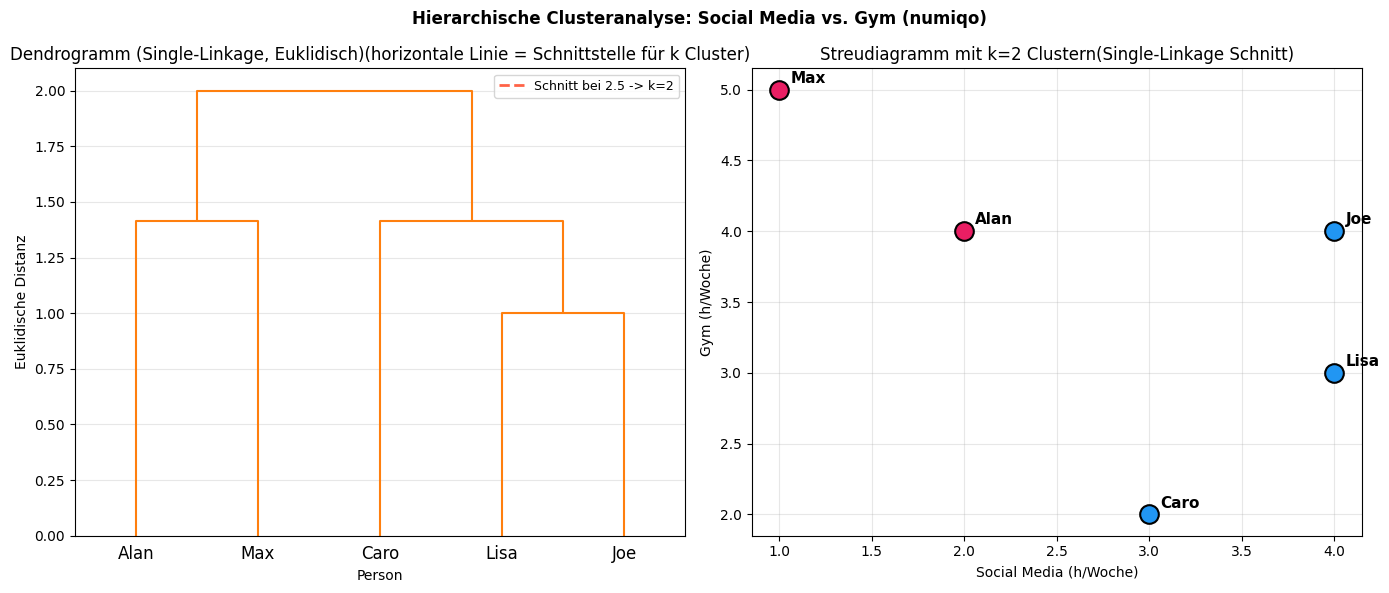

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Hierarchische Clusteranalyse: Social Media vs. Gym (numiqo)",
             fontsize=12, fontweight="bold")

# 1. Dendrogramm
dendrogram(Z, labels=personen, ax=axes[0],
           color_threshold=2.5,
           above_threshold_color="gray",
           leaf_font_size=12)
axes[0].set_title("Dendrogramm (Single-Linkage, Euklidisch)(horizontale Linie = Schnittstelle für k Cluster)")
axes[0].set_xlabel("Person")
axes[0].set_ylabel("Euklidische Distanz")
axes[0].axhline(2.5, color="tomato", linestyle="--", linewidth=2,
                label="Schnitt bei 2.5 -> k=2")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

# 2. Streudiagramm mit Cluster-Zuordnung
labels_k2 = fcluster(Z, t=2, criterion="maxclust")
farben_h  = {1: "#E91E63", 2: "#2196F3", 3: "#4CAF50", 4: "#FF9800"}
for i, (p, pt) in enumerate(zip(personen, X_numiqo)):
    fc = farben_h[labels_k2[i]]
    axes[1].scatter(*pt, color=fc, s=180, zorder=3, edgecolors="black",
                    linewidth=1.5)
    axes[1].annotate(p, pt, textcoords="offset points",
                     xytext=(8, 5), fontsize=11, fontweight="bold")
axes[1].set_title("Streudiagramm mit k=2 Clustern(Single-Linkage Schnitt)")
axes[1].set_xlabel("Social Media (h/Woche)")
axes[1].set_ylabel("Gym (h/Woche)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Distanzmaße im Vergleich

Für Max (1,5) und Caro (3,2): Differenz x=2, y=3

Distanzmasse: Max (1,5) vs. Caro (3,2)
Differenz: x=-2 y=3

Euklidisch:  sqrt(2^2 + 3^2) = sqrt(4+9) = sqrt(13) = 3.6056
Manhattan:   |2| + |3| = 5
Maximum:     max(|2|, |3|) = 3



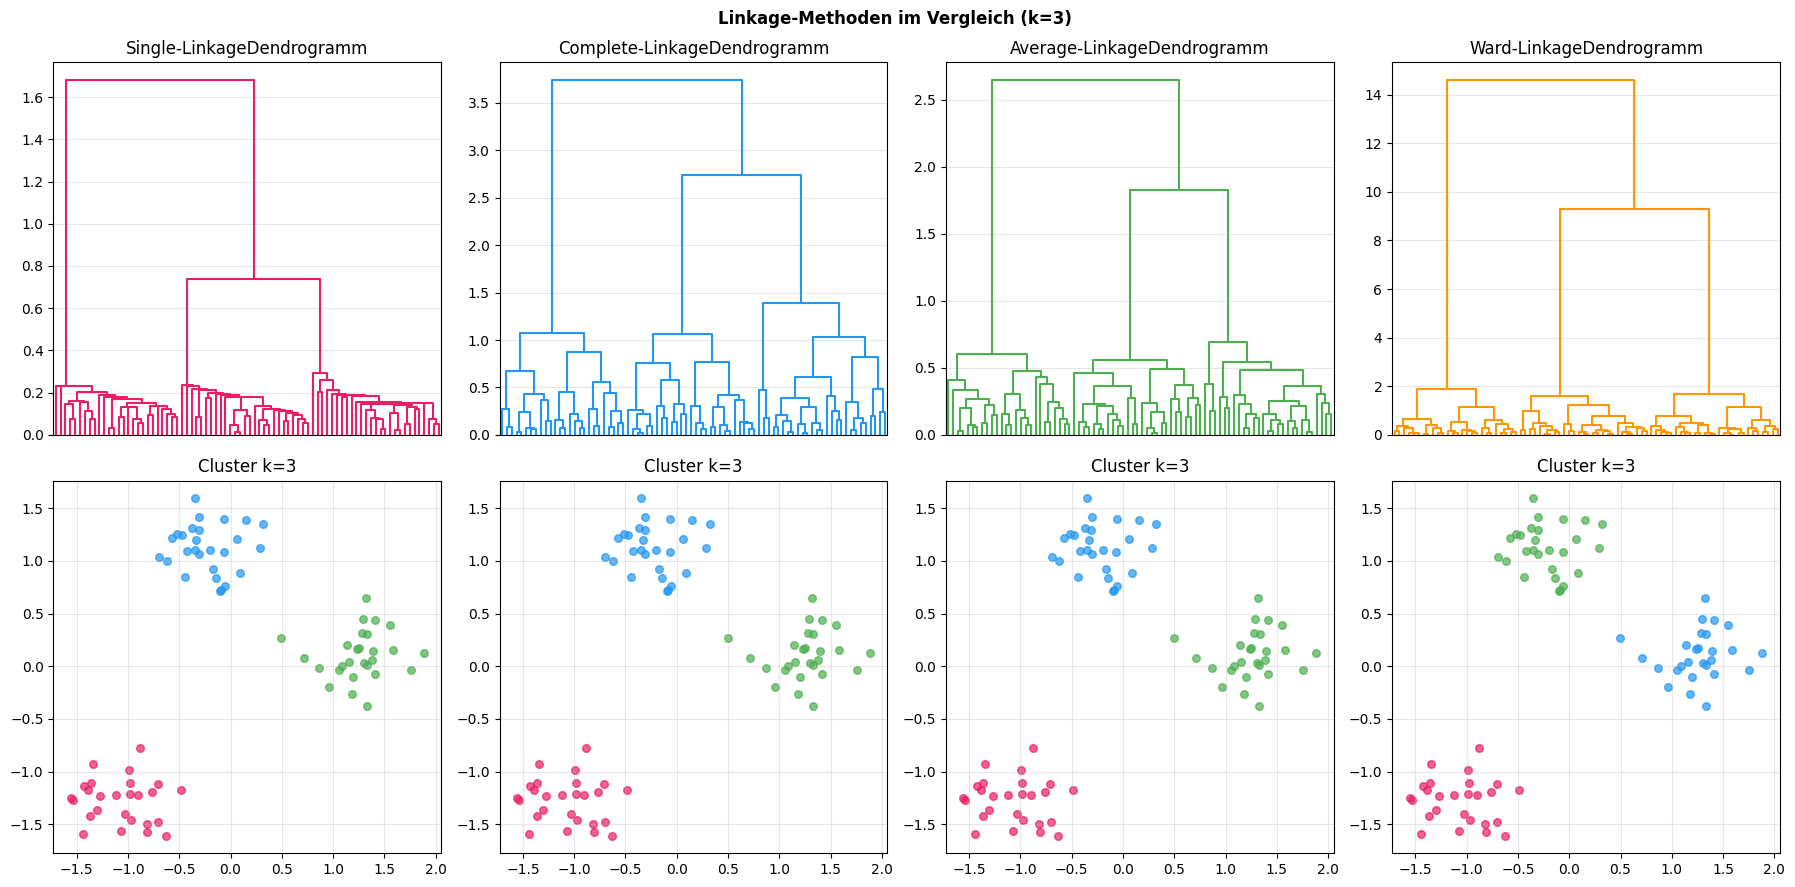

In [4]:
# Distanzmasse demonstrieren (Max vs. Caro)
max_p  = np.array([1, 5])
caro_p = np.array([3, 2])
diff = max_p - caro_p

eukl   = np.sqrt((diff**2).sum())
manhat = np.abs(diff).sum()
maxd   = np.abs(diff).max()

print("Distanzmasse: Max (1,5) vs. Caro (3,2)")
print("Differenz: x=" + str(diff[0]) + " y=" + str(diff[1]))
print()
print("Euklidisch:  sqrt(2^2 + 3^2) = sqrt(4+9) = sqrt(13) = " + str(round(eukl,4)))
print("Manhattan:   |2| + |3| = " + str(int(manhat)))
print("Maximum:     max(|2|, |3|) = " + str(int(maxd)))
print()

# Vier Linkage-Methoden vergleichen
np.random.seed(42)
from sklearn.datasets import make_blobs
X_big, _ = make_blobs(n_samples=80, centers=3, cluster_std=1.5, random_state=42)
X_big_sc = StandardScaler().fit_transform(X_big)

methoden = ["single", "complete", "average", "ward"]
farben_l = ["#E91E63", "#2196F3", "#4CAF50", "#FF9800"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Linkage-Methoden im Vergleich (k=3)", fontsize=12, fontweight="bold")

for col, (method, fc) in enumerate(zip(methoden, farben_l)):
    Z_m = linkage(X_big_sc, method=method)
    labels_m = fcluster(Z_m, t=3, criterion="maxclust")

    dendrogram(Z_m, ax=axes[0, col], color_threshold=0,
               above_threshold_color=fc, no_labels=True)
    axes[0, col].set_title(method.capitalize() + "-LinkageDendrogramm")
    axes[0, col].grid(axis="y", alpha=0.3)

    for j in range(1, 4):
        mask = labels_m == j
        axes[1, col].scatter(X_big_sc[mask, 0], X_big_sc[mask, 1],
                             color=farben_h[j], s=30, alpha=0.7)
    axes[1, col].set_title("Cluster k=3")
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Optimale Clusteranzahl aus dem Dendrogramm ablesen

Die **längste horizontale Verbindung ohne Schnitt** im Dendrogramm zeigt das
optimale k – ähnlich der Elbow-Methode bei k-Means.

Optimale Clusteranzahl (Ward-Linkage)
Letzte 5 Fusionierdistanzen (größte zuerst):
  k=1 -> Distanz=16.5646
  k=2 -> Distanz=10.6974
  k=3 -> Distanz=1.277
  k=4 -> Distanz=1.1965
  k=5 -> Distanz=1.1757

Größter Sprung bei k=3 -> optimales k!


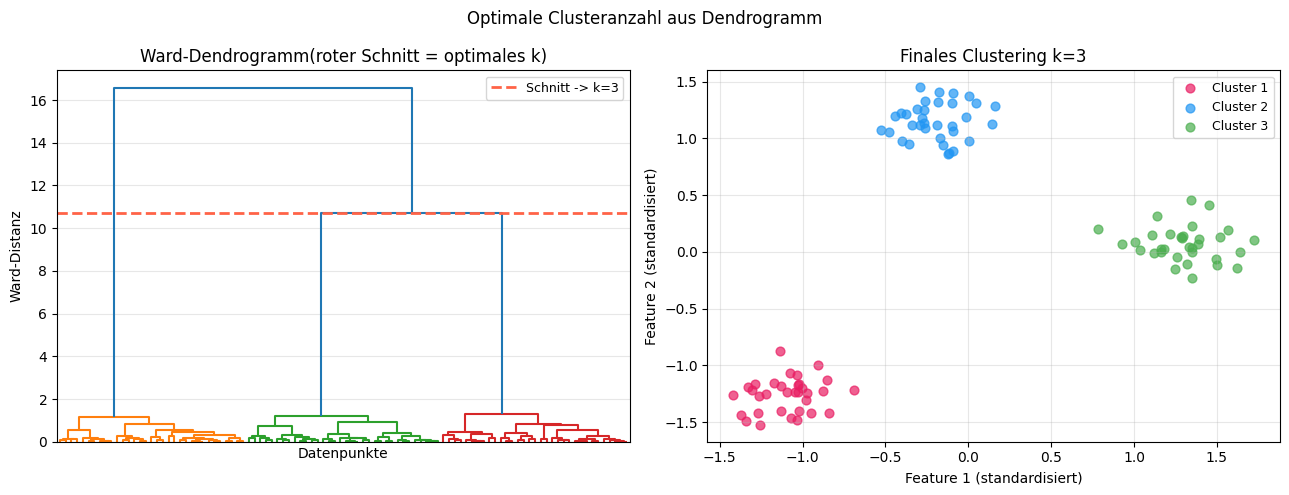

In [5]:
# Optimales k aus Dendrogramm (Ward-Methode)
np.random.seed(42)
X_opt, _ = make_blobs(n_samples=100, centers=3, cluster_std=1.0, random_state=42)
X_opt_sc = StandardScaler().fit_transform(X_opt)
Z_opt    = linkage(X_opt_sc, method="ward")

# Größte Abstandssprünge finden
last_merges = Z_opt[-10:, 2]
acceleration = np.diff(last_merges)
opt_k = int(acceleration[::-1].argmax() + 2)

print("Optimale Clusteranzahl (Ward-Linkage)")
print("Letzte 5 Fusionierdistanzen (größte zuerst):")
for i, d in enumerate(last_merges[::-1][:5]):
    print("  k=" + str(i+1) + " -> Distanz=" + str(round(d, 4)))
print()
print("Größter Sprung bei k=" + str(opt_k) + " -> optimales k!")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Optimale Clusteranzahl aus Dendrogramm", fontsize=12)

dendrogram(Z_opt, ax=axes[0], color_threshold=Z_opt[-(opt_k-1), 2],
           no_labels=True)
axes[0].axhline(Z_opt[-(opt_k-1), 2], color="tomato", linestyle="--",
                linewidth=2, label="Schnitt -> k=" + str(opt_k))
axes[0].set_title("Ward-Dendrogramm(roter Schnitt = optimales k)")
axes[0].set_xlabel("Datenpunkte")
axes[0].set_ylabel("Ward-Distanz")
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

labels_opt = fcluster(Z_opt, t=opt_k, criterion="maxclust")
for j in range(1, opt_k+1):
    mask = labels_opt == j
    axes[1].scatter(X_opt_sc[mask,0], X_opt_sc[mask,1],
                    color=farben_h[j], s=40, alpha=0.7,
                    label="Cluster " + str(j))
axes[1].set_title("Finales Clustering k=" + str(opt_k))
axes[1].set_xlabel("Feature 1 (standardisiert)")
axes[1].set_ylabel("Feature 2 (standardisiert)")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Zusammenfassung

```
Hierarchische Clusteranalyse – Übersicht
│
├── WAS?
│   Erstellt einen Baum (Dendrogramm) der Aehnlichkeiten
│   Agglomerativ (Bottom-Up): n Cluster -> 1 Cluster
│   k muss NICHT vorab festgelegt werden!
│
├── ALGORITHMUS
│   1. Jeder Punkt = eigener Cluster
│   2. Aehnlichste zwei Cluster zusammenlegen
│   3. Abstandsmatrix aktualisieren
│   4. Wiederholen bis 1 Cluster uebrig
│
├── DISTANZMASSE
│   Euklidisch: sqrt(Sum(xi-yi)^2)
│   Manhattan:  Sum(|xi-yi|)
│   Maximum:    max(|xi-yi|)
│
├── LINKAGE-METHODEN
│   Single:   Naechste Punkte (tendiert zu Kettenbildung)
│   Complete: Fernste Punkte (kompakte Cluster)
│   Average:  Mittelwert aller Paare
│   Ward:     Minimale Varianzerhöhung (oft bestes Ergebnis)
│
├── OPTIMALES k AUS DENDROGRAMM
│   Laengste horizontale Verbindung ohne Schnitt
│   = Groesster Abstandssprung
│
├── numiqo-BEISPIEL: Social Media vs. Gym (n=5)
│   Single-Linkage: Joe+Lisa, dann Alan+Max, dann Caro dazu
│
├── VS. k-MEANS
│   Hierarchisch: deterministisch, Dendrogramm, keine k-Vorgabe
│   k-Means: schneller, besser fuer grosse Daten
│
└── PYTHON
    from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
    Z = linkage(X, method="ward", metric="euclidean")
    dendrogram(Z, labels=namen)
    labels = fcluster(Z, t=k, criterion="maxclust")
```

---
Quelle: [numiqo.de/tutorial/hierarchische-clusteranalyse](https://numiqo.de/tutorial/hierarchische-clusteranalyse)